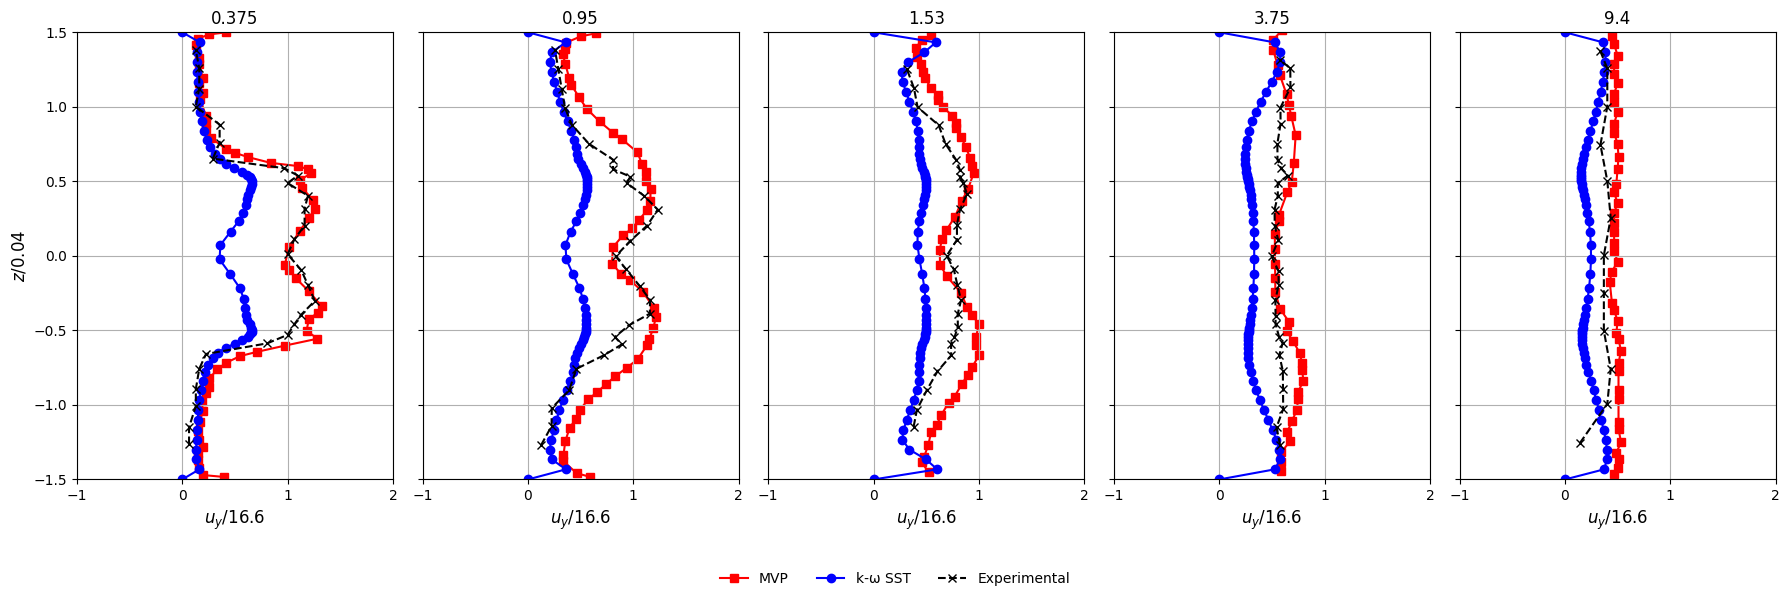


--- Error Results (k-ω SST vs Experimental) ---
Case              MAE       RMSE
0.375             nan        nan
0.95              nan        nan
1.53              nan        nan
3.75              nan        nan
9.4               nan        nan


In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

# === Case setup ===
case_ids = ['0p375', '0p95', '1p53', '3p75', '9p4']
case_titles = ['0.375', '0.95', '1.53', '3.75', '9.4']
rk_keys = ['rk0_375', 'rk0_95', 'rk1_53', 'rk3_75', 'rk9_4']
rb_keys = ['rb0_375', 'rb0_95', 'rb1_53', 'rb3_75', 'rb9_4']

# === Load reference dataset ===
df_ref = pd.read_csv('/home/d/Downloads/all_black_blue_data.csv')

# === Create subplots ===
fig, axes = plt.subplots(1, 5, figsize=(18, 6), sharey=True)

# === Store MAE & RMSE results ===
error_results = []

for i, case in enumerate(case_ids):
    ax = axes[i]

    # --- Load simulation data ---
    sim_file = f'/home/d/ssh_files/rms/{case}.csv'
    df_sim = pd.read_csv(sim_file)[['Points:2', 'UPrime2Mean:1']]
    df_avg = df_sim.groupby('Points:2', as_index=False)['UPrime2Mean:1'].mean()
    z_norm = df_avg['Points:2'] / 0.04
    u_sim = np.sqrt(df_avg['UPrime2Mean:1']) / 16.6

    # --- Experimental Data ---
    x_rk = df_ref[f'{rk_keys[i]}_x']
    y_rk = df_ref[f'{rk_keys[i]}_y']
    df_rk = pd.DataFrame({'x': x_rk, 'y': y_rk}).dropna().sort_values(by='y')
    x_rk_clean = df_rk['x']
    y_rk_clean = df_rk['y']

    # --- MVP data ---
    x_rb = df_ref[f'{rb_keys[i]}_x']
    y_rb = df_ref[f'{rb_keys[i]}_y']
    df_rb = pd.DataFrame({'x': x_rb, 'y': y_rb}).dropna().sort_values(by='y')
    x_rb_sorted = df_rb['x']
    y_rb_sorted = df_rb['y']

    # --- Interpolate experimental data to sim z values ---
    try:
        exp_interp = np.interp(z_norm, y_rk_clean, x_rk_clean)
        mae = mean_absolute_error(exp_interp, u_sim)
        rmse = mean_squared_error(exp_interp, u_sim, squared=False)
    except Exception as e:
        mae = np.nan
        rmse = np.nan

    error_results.append((case_titles[i], mae, rmse))

    # --- Plot ---
    ax.plot(x_rb_sorted, y_rb_sorted, marker='s', linestyle='-', label='MVP', color='red', zorder=1)
    ax.plot(u_sim, z_norm, marker='o', linestyle='-', label='k-ω SST', color='blue', zorder=2)
    ax.plot(x_rk_clean, y_rk_clean, marker='x', linestyle='--', label='Experimental', color='black', zorder=3)

    ax.set_title(f'{case_titles[i]}', fontsize=12)
    ax.set_xlim(-1, 2)
    ax.set_ylim(-1.5, 1.5)
    ax.set_xticks(np.arange(-1, 2.1, 1))
    ax.set_yticks(np.arange(-1.5, 1.6, 0.5))
    ax.grid(True)

    if i == 0:
        ax.set_ylabel(r'$z / 0.04$', fontsize=12)
    ax.set_xlabel(r'$u_y / 16.6$', fontsize=12)

# === Common Legend ===
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=3, fontsize='medium', frameon=False)

plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.show()

# === Print MAE and RMSE Results ===
print("\n--- Error Results (k-ω SST vs Experimental) ---")
print(f"{'Case':<10} {'MAE':>10} {'RMSE':>10}")
for case, mae, rmse in error_results:
    print(f"{case:<10} {mae:10.4f} {rmse:10.4f}")


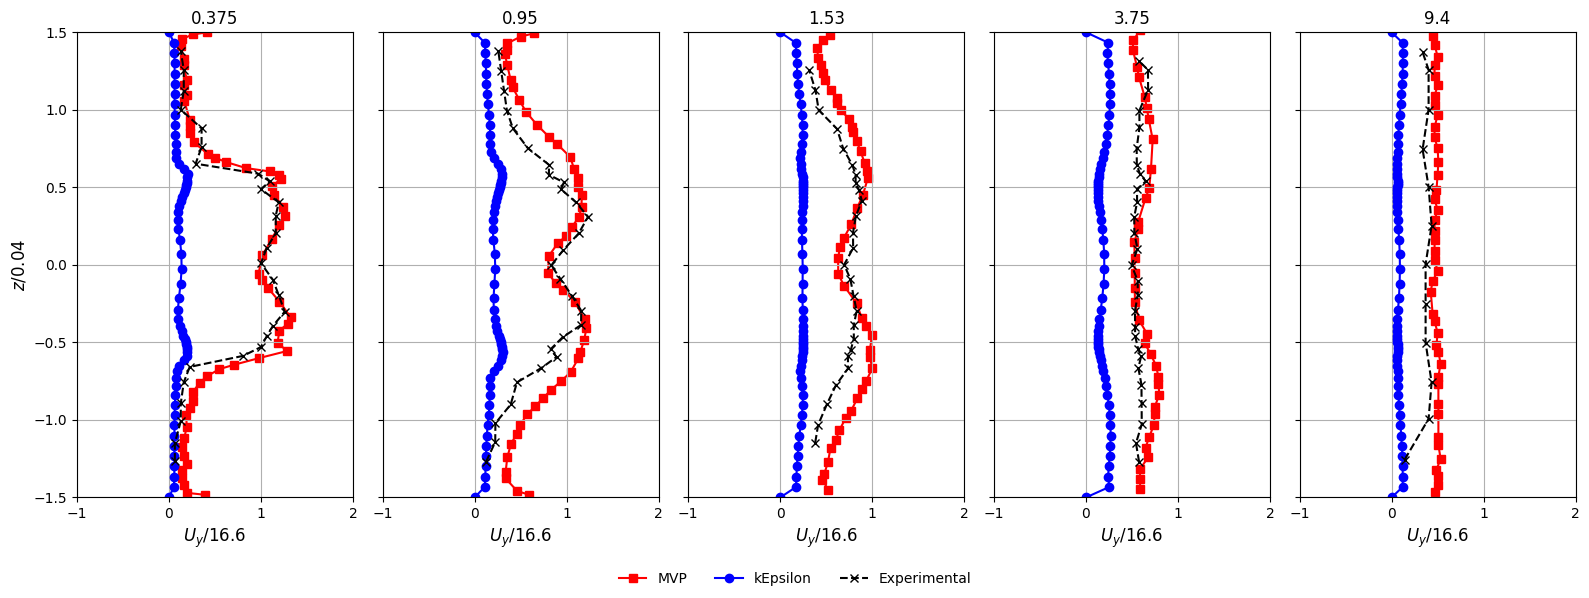


--- Error Results (kEpsilon vs Experimental) ---
Case              MAE       RMSE
0.375          0.5532     0.6999
0.95           0.5146     0.5964
1.53           0.4508     0.4771
3.75           0.3801     0.3834
9.4            0.2801     0.2933


In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

# === Case setup ===
case_ids = ['0p375', '0p95', '1p53', '3p75', '9p4']
case_titles = ['0.375', '0.95', '1.53', '3.75', '9.4']
rk_keys = ['rk0_375', 'rk0_95', 'rk1_53', 'rk3_75', 'rk9_4']
rb_keys = ['rb0_375', 'rb0_95', 'rb1_53', 'rb3_75', 'rb9_4']

# === Load reference data ===
df_ref = pd.read_csv('/home/d/Downloads/all_black_blue_data.csv')

# === Create subplots: 1 row, 5 columns ===
fig, axes = plt.subplots(1, 5, figsize=(16, 6), sharey=True)

# === Store error metrics ===
error_results = []

for i, case in enumerate(case_ids):
    ax = axes[i]

    # --- Load simulation data ---
    sim_file = f'/home/d/ssh_files/new_kEp/{case}.csv'
    df_sim = pd.read_csv(sim_file)
    df_sim = df_sim[['Points:2', 'UPrime2Mean:1']]
    df_avg = df_sim.groupby('Points:2', as_index=False)['UPrime2Mean:1'].mean()
    z_norm = df_avg['Points:2'] / 0.04
    u_norm = np.sqrt(df_avg['UPrime2Mean:1']) / 16.6

    # --- Experimental data (used for error computation) ---
    x_rk = df_ref[f'{rk_keys[i]}_x']
    y_rk = df_ref[f'{rk_keys[i]}_y']
    df_rk = pd.DataFrame({'x': x_rk, 'y': y_rk}).dropna().sort_values(by='y')
    x_rk_sorted = df_rk['x']
    y_rk_sorted = df_rk['y']

    # --- MVP data (for plotting only) ---
    x_rb = df_ref[f'{rb_keys[i]}_x']
    y_rb = df_ref[f'{rb_keys[i]}_y']
    df_rb = pd.DataFrame({'x': x_rb, 'y': y_rb}).dropna().sort_values(by='y')
    x_rb_sorted = df_rb['x']
    y_rb_sorted = df_rb['y']

    # --- Error metrics (simulation vs experimental) ---
    sim_interp = np.interp(y_rk_sorted, z_norm, u_norm)
    mae = mean_absolute_error(x_rk_sorted, sim_interp)
    rmse = np.sqrt(mean_squared_error(x_rk_sorted, sim_interp))
    error_results.append((case_titles[i], mae, rmse))

    # --- Plot curves ---
    ax.plot(x_rb_sorted, y_rb_sorted, marker='s', linestyle='-', label='MVP', color='red', zorder=1)
    ax.plot(u_norm, z_norm, marker='o', linestyle='-', label='kEpsilon', color='blue', zorder=2)
    ax.plot(x_rk_sorted, y_rk_sorted, marker='x', linestyle='--', label='Experimental', color='black', zorder=3)

    ax.set_title(f'{case_titles[i]}')
    ax.set_xlim(-1, 2)
    ax.set_ylim(-1.5, 1.5)
    ax.set_xticks(np.arange(-1, 2.1, 1))
    ax.set_yticks(np.arange(-1.5, 1.6, 0.5))
    ax.grid(True)

    if i == 0:
        ax.set_ylabel(r'$z / 0.04$', fontsize=12)
    ax.set_xlabel(r'$U_y / 16.6$', fontsize=12)

# === Add common legend ===
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=3, fontsize='medium', frameon=False)

plt.tight_layout(rect=[0, 0.05, 1, 1])  # make space for legend
fig.savefig('/home/d/ssh_files/transient2_kEpsilon/fig6b_axial_rms_exp_error.png', dpi=300)
plt.show()

# === Print error results ===
print("\n--- Error Results (kEpsilon vs Experimental) ---")
print(f"{'Case':<10} {'MAE':>10} {'RMSE':>10}")
for case, mae, rmse in error_results:
    print(f"{case:<10} {mae:10.4f} {rmse:10.4f}")


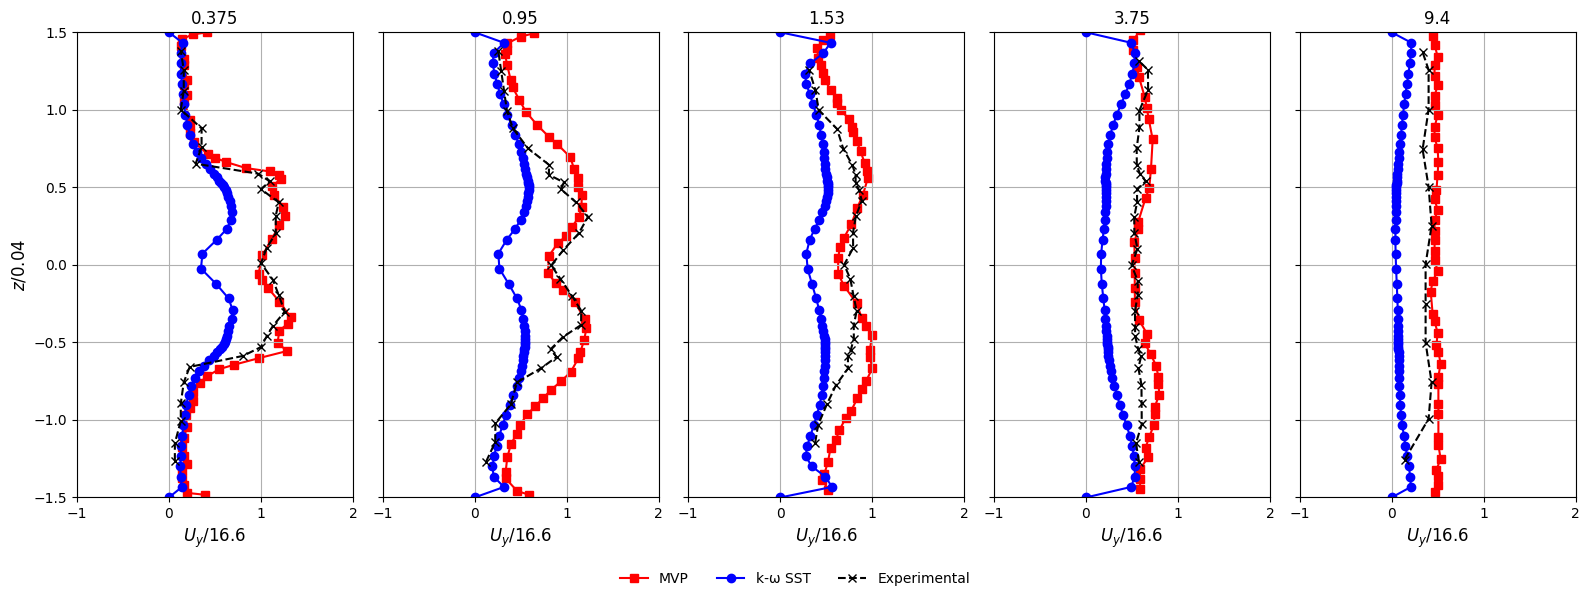


--- Error Results (k-ω SST vs Experimental) ---
Case              MAE       RMSE
0.375          0.3082     0.3881
0.95           0.3104     0.4015
1.53           0.2672     0.3012
3.75           0.2855     0.3033
9.4            0.2673     0.2844


In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

# === Case setup ===
case_ids = ['0p375', '0p95', '1p53', '3p75', '9p4']
case_titles = ['0.375', '0.95', '1.53', '3.75', '9.4']
rk_keys = ['rk0_375', 'rk0_95', 'rk1_53', 'rk3_75', 'rk9_4']
rb_keys = ['rb0_375', 'rb0_95', 'rb1_53', 'rb3_75', 'rb9_4']

# === Load reference data ===
df_ref = pd.read_csv('/home/d/Downloads/all_black_blue_data.csv')

# === Create subplots: 1 row, 5 columns ===
fig, axes = plt.subplots(1, 5, figsize=(16, 6), sharey=True)

# === Store error metrics ===
error_results = []

for i, case in enumerate(case_ids):
    ax = axes[i]

    # --- Load simulation data ---
    sim_file = f'/home/d/ssh_files/rms7_15/{case}.csv'
    df_sim = pd.read_csv(sim_file)
    df_sim = df_sim[['Points:2', 'UPrime2Mean:1']]
    df_avg = df_sim.groupby('Points:2', as_index=False)['UPrime2Mean:1'].mean()
    z_norm = df_avg['Points:2'] / 0.04
    u_norm = np.sqrt(df_avg['UPrime2Mean:1']) / 16.6

    # --- Experimental data (used for error computation) ---
    x_rk = df_ref[f'{rk_keys[i]}_x']
    y_rk = df_ref[f'{rk_keys[i]}_y']
    df_rk = pd.DataFrame({'x': x_rk, 'y': y_rk}).dropna().sort_values(by='y')
    x_rk_sorted = df_rk['x']
    y_rk_sorted = df_rk['y']

    # --- MVP data (for plotting only) ---
    x_rb = df_ref[f'{rb_keys[i]}_x']
    y_rb = df_ref[f'{rb_keys[i]}_y']
    df_rb = pd.DataFrame({'x': x_rb, 'y': y_rb}).dropna().sort_values(by='y')
    x_rb_sorted = df_rb['x']
    y_rb_sorted = df_rb['y']

    # --- Error metrics (simulation vs experimental) ---
    sim_interp = np.interp(y_rk_sorted, z_norm, u_norm)
    mae = mean_absolute_error(x_rk_sorted, sim_interp)
    rmse = np.sqrt(mean_squared_error(x_rk_sorted, sim_interp))
    error_results.append((case_titles[i], mae, rmse))

    # --- Plot curves ---
    ax.plot(x_rb_sorted, y_rb_sorted, marker='s', linestyle='-', label='MVP', color='red', zorder=1)
    ax.plot(u_norm, z_norm, marker='o', linestyle='-', label='k-ω SST', color='blue', zorder=2)
    ax.plot(x_rk_sorted, y_rk_sorted, marker='x', linestyle='--', label='Experimental', color='black', zorder=3)

    ax.set_title(f'{case_titles[i]}')
    ax.set_xlim(-1, 2)
    ax.set_ylim(-1.5, 1.5)
    ax.set_xticks(np.arange(-1, 2.1, 1))
    ax.set_yticks(np.arange(-1.5, 1.6, 0.5))
    ax.grid(True)

    if i == 0:
        ax.set_ylabel(r'$z / 0.04$', fontsize=12)
    ax.set_xlabel(r'$U_y / 16.6$', fontsize=12)

# === Add common legend ===
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=3, fontsize='medium', frameon=False)

plt.tight_layout(rect=[0, 0.05, 1, 1])  # make space for legend
fig.savefig('/home/d/ssh_files/transient2_kOmegaSST_2/fig6b_axial_rms_exp_error.png', dpi=300)
plt.show()

# === Print error results ===
print("\n--- Error Results (k-ω SST vs Experimental) ---")
print(f"{'Case':<10} {'MAE':>10} {'RMSE':>10}")
for case, mae, rmse in error_results:
    print(f"{case:<10} {mae:10.4f} {rmse:10.4f}")
